In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load dataset
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # Add target column

# View first few rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.

In [3]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


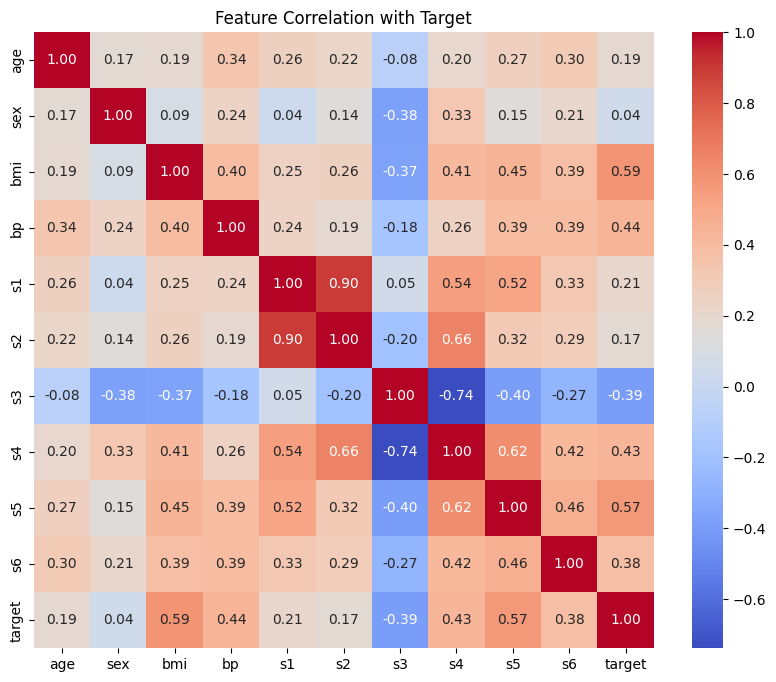

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation with Target")
plt.show()

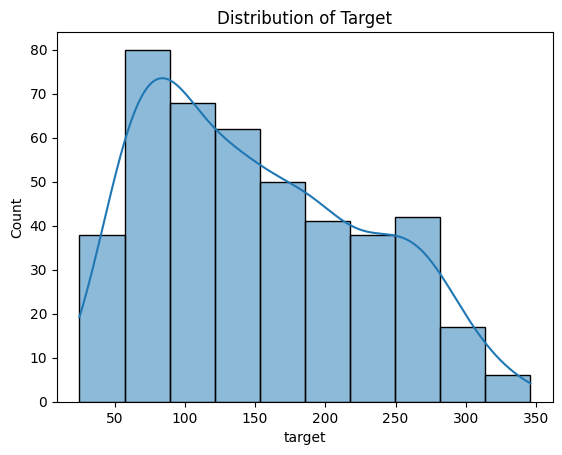

In [5]:
sns.histplot(df['target'], kde=True)
plt.title("Distribution of Target")
plt.show()

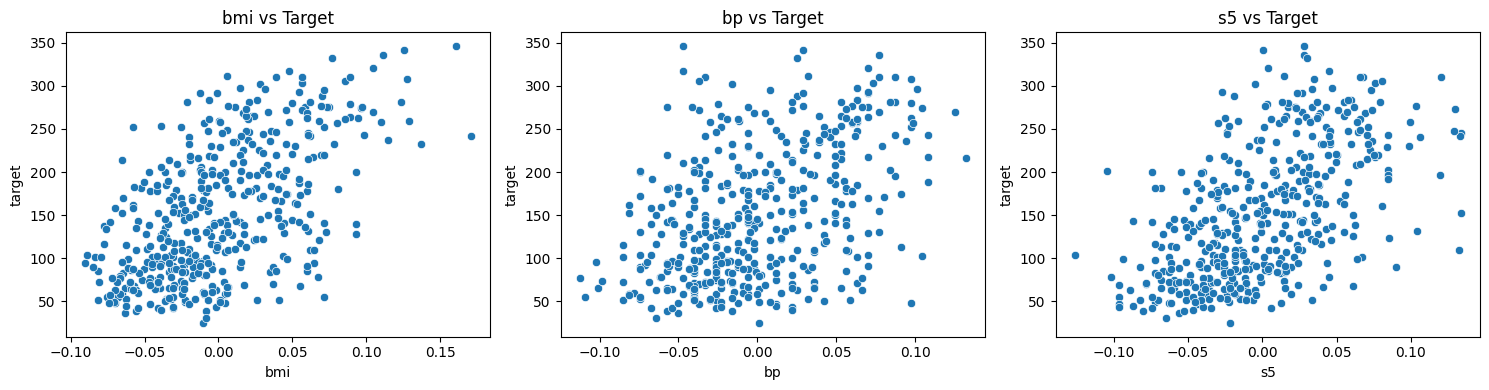

In [6]:
features_to_plot = ['bmi', 'bp', 's5']

plt.figure(figsize=(15, 4))
for i, feature in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=df[feature], y=df['target'])
    plt.title(f"{feature} vs Target")
plt.tight_layout()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

```Linear regression```

Simple Linear Regression R² Score: 0.3439237602253802


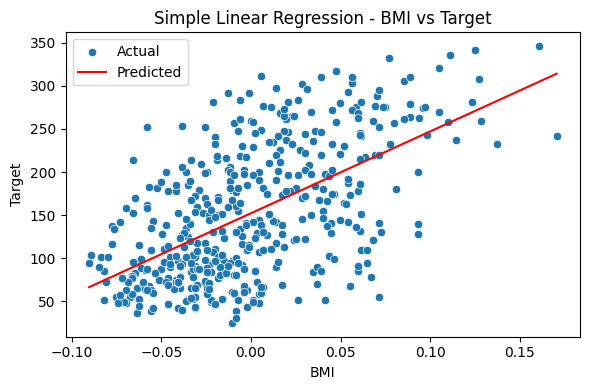

In [10]:
# Feature and target
X_simple = df[['bmi']]
y = df['target']

# Fit model
model_simple = LinearRegression()
model_simple.fit(X_simple, y)

# Predictions
y_pred_simple = model_simple.predict(X_simple)

# R² Score
print("Simple Linear Regression R² Score:", r2_score(y, y_pred_simple))

# Visualization
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['bmi'], y=y, label='Actual')
sns.lineplot(x=df['bmi'], y=y_pred_simple, color='red', label='Predicted')
plt.title("Simple Linear Regression - BMI vs Target")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

```Multiple Linear Regression```

Multiple Linear Regression R² Score: 0.5177484222203499


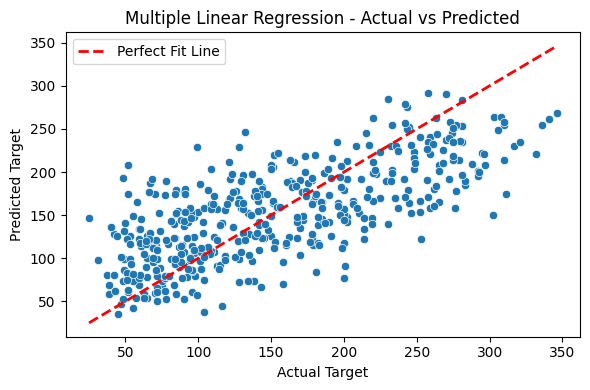

In [13]:
# Fit model
model_multiple = LinearRegression()
model_multiple.fit(X, y)

# Predictions
y_pred_multiple = model_multiple.predict(X)

# R² Score
print("Multiple Linear Regression R² Score:", r2_score(y, y_pred_multiple))

# Scatter plot of Actual vs Predicted
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y, y=y_pred_multiple)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Multiple Linear Regression - Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

Polynomial Regression R² Score: 0.3440509870104119


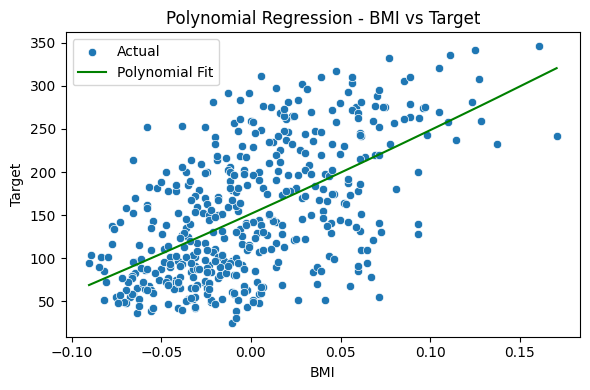

In [12]:
# Transform feature
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_simple)

# Fit model
model_poly = LinearRegression()
model_poly.fit(X_poly, y)

# Predictions
y_pred_poly = model_poly.predict(X_poly)

# R² Score
print("Polynomial Regression R² Score:", r2_score(y, y_pred_poly))

# Visualization
plt.figure(figsize=(6, 4))
# Sort for smooth curve
sorted_bmi = np.sort(df['bmi'])
sorted_index = df['bmi'].argsort()
sorted_pred = y_pred_poly[sorted_index]

sns.scatterplot(x=df['bmi'], y=y, label='Actual')
plt.plot(sorted_bmi, sorted_pred, color='green', label='Polynomial Fit')
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("Polynomial Regression - BMI vs Target")
plt.legend()
plt.tight_layout()
plt.show()

``` Calculate Metrics for All Three Models```

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Simple Linear Regression
mae_simple = mean_absolute_error(y, y_pred_simple)
mse_simple = mean_squared_error(y, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y, y_pred_simple)

# Multiple Linear Regression
mae_multiple = mean_absolute_error(y, y_pred_multiple)
mse_multiple = mean_squared_error(y, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y, y_pred_multiple)

# Polynomial Regression
mae_poly = mean_absolute_error(y, y_pred_poly)
mse_poly = mean_squared_error(y, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y, y_pred_poly)

# Display in a table format
import pandas as pd

results = pd.DataFrame({
    "Model": ["Simple Linear", "Multiple Linear", "Polynomial"],
    "MAE": [mae_simple, mae_multiple, mae_poly],
    "MSE": [mse_simple, mse_multiple, mse_poly],
    "RMSE": [rmse_simple, rmse_multiple, rmse_poly],
    "R2 Score": [r2_simple, r2_multiple, r2_poly]
})

print(results)


             Model        MAE          MSE       RMSE  R2 Score
0    Simple Linear  51.798628  3890.456585  62.373525  0.343924
1  Multiple Linear  43.277452  2859.696348  53.476129  0.517748
2       Polynomial  51.779027  3889.702145  62.367477  0.344051


```Ridge, Lasso, and Elastic Net```

In [15]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # Import train_test_split here

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Adjust test_size and random_state as needed

In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_preds = ridge.predict(X_test)

print("Ridge Regression")
print("MAE:", mean_absolute_error(y_test, ridge_preds))
print("MSE:", mean_squared_error(y_test, ridge_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_preds))) # Calculate RMSE by taking the square root of MSE
print("R2 Score:", r2_score(y_test, ridge_preds))

Ridge Regression
MAE: 46.13885766697452
MSE: 3077.41593882723
RMSE: 55.47446204180109
R2 Score: 0.41915292635986545


In [24]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_preds = lasso.predict(X_test)

print("\nLasso Regression")
print("MAE:", mean_absolute_error(y_test, lasso_preds))
print("MSE:", mean_squared_error(y_test, lasso_preds))
# Calculate RMSE manually using NumPy
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_preds)))
print("R2 Score:", r2_score(y_test, lasso_preds))


Lasso Regression
MAE: 42.85442771664998
MSE: 2798.193485169719
RMSE: 52.897953506442185
R2 Score: 0.4718547867276227


In [26]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5 balances L1 and L2
elastic.fit(X_train, y_train)
elastic_preds = elastic.predict(X_test)

print("\nElastic Net Regression")
print("MAE:", mean_absolute_error(y_test, elastic_preds))
print("MSE:", mean_squared_error(y_test, elastic_preds))
# Calculate RMSE using NumPy to ensure compatibility
print("RMSE:", np.sqrt(mean_squared_error(y_test, elastic_preds)))
print("R2 Score:", r2_score(y_test, elastic_preds))


Elastic Net Regression
MAE: 60.3498426167246
MSE: 4775.466767154695
RMSE: 69.10475213149017
R2 Score: 0.09865421116113748


```Visualizing the results```

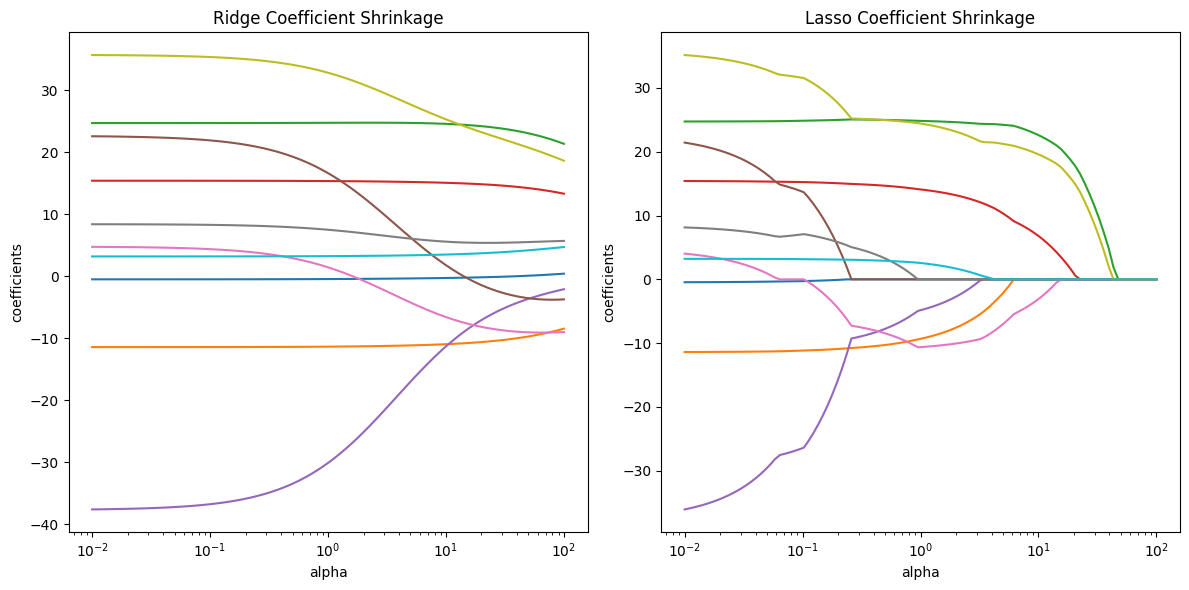

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes

# Load data
X, y = load_diabetes(return_X_y=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-2, 2, 100)
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled, y)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_scaled, y)
    lasso_coefs.append(lasso.coef_)

# Plotting
plt.figure(figsize=(12, 6))

# Ridge Coefficients
plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_coefs)
plt.xscale('log')
plt.title('Ridge Coefficient Shrinkage')
plt.xlabel('alpha')
plt.ylabel('coefficients')

# Lasso Coefficients
plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_coefs)
plt.xscale('log')
plt.title('Lasso Coefficient Shrinkage')
plt.xlabel('alpha')
plt.ylabel('coefficients')

plt.tight_layout()
plt.show()

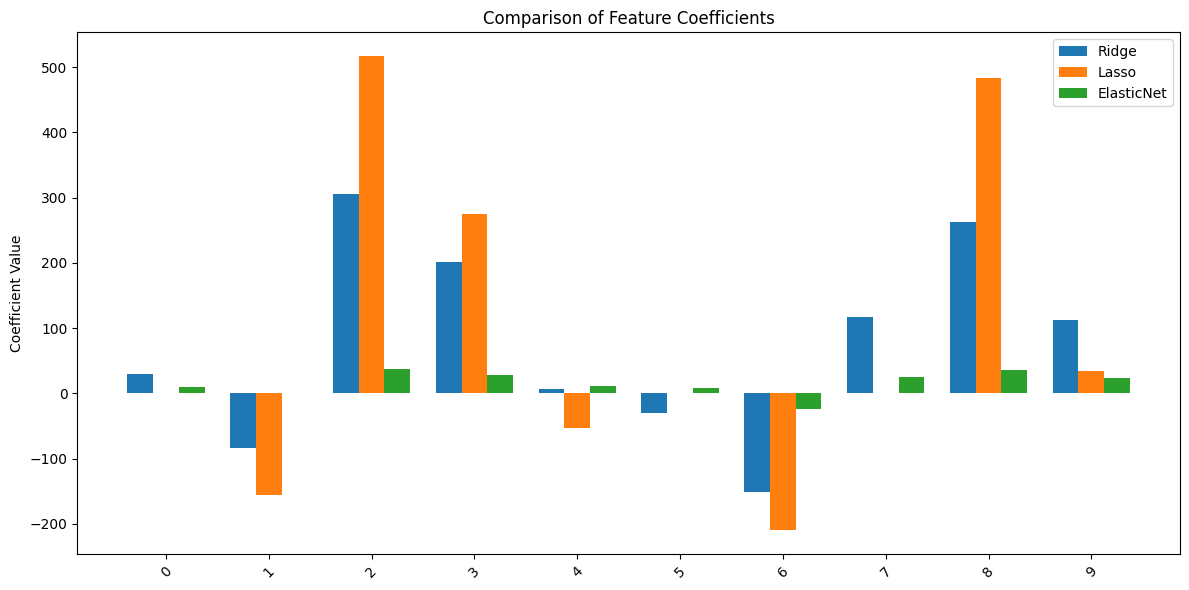

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Import pandas

# Assuming the model is already fit and you're using the same features
# Convert X to a pandas DataFrame if it's not already
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)
    # If you have original feature names, you can assign them here
    # X.columns = ['feature_name_1', 'feature_name_2', ...]
    # Otherwise, default column names will be used (0, 1, 2, ...)

feature_names = X.columns

# Fit models with desired alpha (e.g., alpha=1.0 for Ridge)
ridge_model = Ridge(alpha=1.0) # Define ridge_model here
ridge_model.fit(X, y) # Fit the ridge model

lasso_model = Lasso(alpha=0.1) # Define lasso_model here
lasso_model.fit(X, y) # Fit the lasso model

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5) # Define elastic_model here
elastic_model.fit(X, y) # Fit the elastic net model

# Coefficients
ridge_coefs = ridge_model.coef_
lasso_coefs = lasso_model.coef_
elastic_coefs = elastic_model.coef_

x = np.arange(len(feature_names))  # index for each feature
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, ridge_coefs, width, label='Ridge')
plt.bar(x, lasso_coefs, width, label='Lasso')
plt.bar(x + width, elastic_coefs, width, label='ElasticNet')
plt.xticks(x, feature_names, rotation=45)
plt.ylabel('Coefficient Value')
plt.title('Comparison of Feature Coefficients')
plt.legend()
plt.tight_layout()
plt.show()

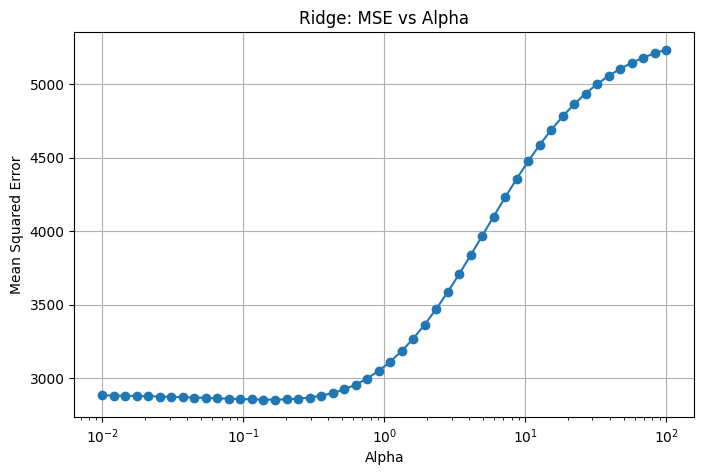

In [29]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

alphas = np.logspace(-2, 2, 50)
ridge_mse = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    ridge_mse.append(mse)

plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_mse, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Ridge: MSE vs Alpha')
plt.grid(True)
plt.show()